In [1]:
# ================= PORT NA KONWENCJE ARTYKULU (06.09.2026) =================
# PORT 20260905b.ipynb. Zmiany wzgledem oryginalu, wszystkie zamierzone:
#  1. statystyka liczona przez ../statystyka.py w konwencji kodu zespolu;
#  2. MOSKWA czytana z pliku CR z archiwum CREDO (zrodla/kod/dane/mosc_data2.csv)
#     zamiast z naszego pobrania z NMDB. To jest dokladnie ten przypadek, dla
#     ktorego Maciek zdecydowal 05.09, ze wersja pliku CR ma sie zmieniac:
#     zestawiamy tu nasze liczby z OPUBLIKOWANYMI. Nasz plik i archiwalny sa
#     identyczne do konca 2009 roku, a rozne po 2010 - a okno sekcji 3 Moskwy
#     (2013-11 .. 2018-06) lezy w calosci po 2010;
#  3. OULU zostaje na naszym pliku 5-minutowym. Archiwum ma wprawdzie
#     oulu_data.csv, ale to szereg ANOMALII PROCENTOWYCH (wartosci w rodzaju
#     0,831 i -0,869), a filtr konwencji zespolu wymaga cr mean > 0 - na
#     szeregu procentowym wyrzucalby wszystkie kosze o ujemnej anomalii, czyli
#     okolo polowy. Zestawienie obu stacji na plikach o roznej naturze byloby
#     nieporownywalne;
#  4. wyjscia z przedrostkiem credo_, zeby nie nadpisac wynikow z 05.09.
# Reszta - pytania, kontrole, reguly odczytu i wykresy - NIETKNIETA.
# ==========================================================================

# 05.09.2026 - 20260905b.ipynb: KTORE OPUBLIKOWANE LICZBY ODTWARZAMY, A KTORYCH NIE.
#
# JEDEN watek (konwencja repo). Watek 20260905a.ipynb dotyczyl SEKCJI 4 (okno
# P=3350, piec minimow). Ten dotyczy SEKCJI 3 - naglownego wyniku ~6 sigma,
# okno P=1675 - i jest odpowiedzia na uwage Maćka po odpaleniu 20260905a:
# "daty wygladaja spot-on ale wartosci nie za bardzo".
#
# DLACZEGO WLASNIE TU. Sekcja 3 jest jedynym miejscem w artykule, gdzie podane
# sa LICZBY CALKOWITE (N+ i N-), a nie tylko p-wartosci. Liczba calkowita jest
# nieporownanie ostrzejszym testem niz PPDF: PPDF na 331 koszach zmienia sie o
# rzad wielkosci przy przesunieciu N+ o kilka jednostek, wiec zgodnosc "co do
# rzedu" niczego nie dowodzi, a zgodnosc "co do jednego kosza" - owszem.
#
# CZTERY OPUBLIKOWANE PUNKTY ODNIESIENIA (sekcja 3, str. 3-4):
#   (a) M(Sm, P) = 859,55 - mediana sum magnitud w oknie przykladu Augera.
#       ZALEZY WYLACZNIE OD KATALOGU TRZESIEN, w ogole nie od danych CR. To
#       jedyna w calym artykule liczba, ktora izoluje jedno zrodlo danych.
#   (b) Moskwa, przepis Augera zastosowany BEZ ZMIAN (t0 = 2 Apr 2014
#       22:07:12): N+ = 199, N- = 132, ok. 3,5 sigma. BEZ optymalizacji t0.
#   (c) Moskwa, t0 DOSTROJONE do Moskwy skanem po 13 400 kandydatach
#       (t0 = 14 Nov 2013 07:00:00): N+ = 218, N- = 113, PCDF = 4,1e-9.
#   (d) Oulu, t0 dostrojone (t0 = 4 Jan 2014 23:37:12): N+ = 220, N- = 112,
#       PCDF = 1,6e-9.
# Roznica miedzy (b) a (c)/(d) jest kluczowa: (b) to przepis wziety z gotowego,
# (c) i (d) to NAJLEPSZY punkt ze skanu po 13 400 polozeniach okna. Jesli
# odtwarzamy (b), a nie odtwarzamy (c)/(d), to nie jest usterka naszego
# pipeline'u - to jest wlasnosc optymalizacji po szumnym krajobrazie.
#
# PARAMETRY: P = 1675 dni (NIE 3350 jak w sekcji 4), d = 5, m = 4,0, dt = 15.
# Implementacja: wylacznie referencyjna `cosmoseismic_stat` (patrz 20260905a
# komorka 1 - dwie implementacje nie sa wymienne co do bitu).
#
# KOSZT: komorka 0 wczytuje Oulu z pliku 5-minutowego i przepropbkowuje na 6 h -
# to ok. 200 MB i kilkadziesiat sekund samego wczytywania. Komorki 1-2 sa
# natychmiastowe. Komorki 3 i 4 to dwa realne skany po
# 13 400 kandydatow (po jednym na stacje), lacznie ok. 1-2 min rownolegle.
import os
import sys
import time

import numpy as np
import pandas as pd
from scipy.stats import binom, norm

sys.path.insert(0, "..")
from mc_parallel import run_t0_scan_parallel

RESULTS_DIR = "../results"
MOSC_PATH = "../źródła/kod/dane/mosc_data2.csv"   # archiwum CREDO (pkt 2 naglowka)
OULU_PATH = "../data/oulu_5min_data.csv"
USGS_PATH = "../data/usgs_data/usgs_m4_1965_2025.csv"

P_DAYS = 1675      # sekcja 3 (~4,5 roku), NIE 3350
D_DAYS = 5
M_THRESHOLD = 4.0
DT_DAYS = 15

# Poczatek skanu t0 w sekcji 3: "beginning from March 30, 2005 (the data of the
# first record in the Auger database) with a step of 6 h ... i.e. checking
# 13,400 partly overlapping periods".
SKAN_START = pd.Timestamp("2005-03-30")
SKAN_N = 13400
SKAN_KROK = pd.Timedelta(hours=6)

ODNIESIENIA = pd.DataFrame([
    dict(etykieta="Moskwa, przepis Augera bez zmian", stacja="mosc",
         t0=pd.Timestamp("2014-04-02 22:07:12"), Np=199, Nm=132, PCDF=np.nan, optymalizowane=False),
    dict(etykieta="Moskwa, t0 dostrojone skanem", stacja="mosc",
         t0=pd.Timestamp("2013-11-14 07:00:00"), Np=218, Nm=113, PCDF=4.1e-9, optymalizowane=True),
    dict(etykieta="Oulu, t0 dostrojone skanem", stacja="oulu",
         t0=pd.Timestamp("2014-01-04 23:37:12"), Np=220, Nm=112, PCDF=1.6e-9, optymalizowane=True),
])


def load_mosc():
    df = pd.read_csv(MOSC_PATH)
    df["datetime"] = pd.to_datetime(df["datetime"])
    return df.set_index("datetime").sort_index()["value"]


def load_oulu():
    # errors="coerce" + dropna: jeden uszkodzony wiersz w pliku Oulu (linia
    # 839815, luka ~15 dni w 1978) - konwencja z 20260716b/20260826d.
    df = pd.read_csv(OULU_PATH)
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    df = df.dropna(subset=["datetime"])
    return df.set_index("datetime").sort_index()["value"].resample("6h").mean()


def load_earthquakes(min_mag=M_THRESHOLD):
    df = pd.read_csv(USGS_PATH, usecols=["time", "mag"])
    df["time"] = pd.to_datetime(df["time"], utc=True).dt.tz_localize(None)
    df = df[df["mag"] >= min_mag]
    return df.set_index("time")["mag"].sort_index()


# Implementacja referencyjna, przepisana znak w znak z 20260824f.ipynb, ale
# zwracajaca DODATKOWO wielkosci posrednie, ktore artykul publikuje: obie
# mediany i rozklad znakow A/B potrzebny do sprawdzenia rownania (4).
sys.path.insert(0, "..")
import importlib

import statystyka as st
importlib.reload(st)   # statystyka.py jest w trakcie rozwoju; bez reload jadro
                       # trzyma wersje z pierwszego importu i zmiany na dysku sa
                       # niewidoczne az do restartu kernela

# KONWENCJA ARTYKULU. Do 05.09 ten notebook liczyl wlasna kopia statystyki w
# naszej starej konwencji; od 06.09 liczy przez wspolny modul ../statystyka.py
# w konwencji kodu zespolu (okno o kosz wczesniej, krata zakotwiczona w
# pierwszym dostepnym rekordzie, mediany po filtrze, filtr skrocony, remisy w
# mianowniku). Uzasadnienie: dziennik 20260905.txt pkt 13a-13g; walidacja
# (odtworzenie tabeli koszy zespolu kosz w kosz): 20260906a.ipynb.
KONWENCJA = st.CREDO


def cosmoseismic_stat(cr, eq, t0, P_days, d_days, m, dt_days):
    """Interfejs bez zmian wzgledem 20260905b - te same klucze slownika, zeby
    reszta notebooka byla NIETKNIETA. Doszly dwa: remisow i dt_efektywne_d."""
    r = st.kosze_ref(cr, eq, t0, P_days, d_days, dt_days, konw=KONWENCJA)
    if r is None:
        return dict(N=int(P_days // d_days), N_valid=0, Np=0, Nm=0, PPDF=np.nan,
                    PCDF=np.nan, sigma=np.nan, med_Sm=np.nan, med_dCR=np.nan,
                    nA_dod=0, nA_uj=0, nB_dod=0, nB_uj=0, remisow=0,
                    dt_efektywne_d=np.nan)
    w = r["wazne"]
    return dict(N=r["N"], N_valid=r["N_valid"], Np=r["Np"], Nm=r["Nm"],
                PPDF=r["PPDF"], PCDF=r["PCDF"], sigma=r["sigma"],
                med_Sm=r["med_Sm"], med_dCR=r["med_dCR"],
                nA_dod=int((r["A"][w] > 0).sum()), nA_uj=int((r["A"][w] < 0).sum()),
                nB_dod=int((r["B"][w] > 0).sum()), nB_uj=int((r["B"][w] < 0).sum()),
                remisow=r["remisow"], dt_efektywne_d=r["dt_efektywne_d"])


CR = {"mosc": load_mosc(), "oulu": load_oulu()}
eq = load_earthquakes()
for _s, _v in CR.items():
    print(f"{_s}: {len(_v):>7} punktow 6h, {_v.index.min()} .. {_v.index.max()}, "
          f"brakow: {int(_v.isna().sum())}")
print(f"EQ: {len(eq)} zdarzen M >= {M_THRESHOLD}")
print(f"Parametry sekcji 3: P={P_DAYS} d (N={P_DAYS // D_DAYS} koszy), d={D_DAYS} d, "
      f"M>={M_THRESHOLD}, dt={DT_DAYS} d")


mosc:   85428 punktow 6h, 1960-01-01 06:00:00 .. 2019-12-11 06:00:00, brakow: 0
oulu:   81816 punktow 6h, 1970-01-01 00:00:00 .. 2025-12-31 18:00:00, brakow: 1756
EQ: 507919 zdarzen M >= 4.0
Parametry sekcji 3: P=1675 d (N=335 koszy), d=5 d, M>=4.0, dt=15 d


In [2]:
# KOMORKA 1 - PUNKT (a): KATALOG TRZESIEN, IZOLOWANY.
# Artykul podaje dla przykladu Augera (t0 = 2 Apr 2014 22:07:12, P=1675, d=5,
# m=4,0, dt=15) mediane sum magnitud M(Sm, P) = 859,55. Ta liczba nie zawiera
# ani jednej wielkosci z detektora promieniowania kosmicznego - jesli sie
# zgadza, nasz katalog i nasze binowanie EQ sa zweryfikowane niezaleznie od
# wszystkiego innego. Dodatkowo: jaki prog magnitudy m bylby potrzebny, zeby
# trafic w ich liczbe, gdyby sie NIE zgadzala.
T0_AUGER = pd.Timestamp("2014-04-02 22:07:12")
MED_SM_ARTYKUL = 859.55


def mediana_Sm(t0, m, P_days=P_DAYS, d_days=D_DAYS, dt_days=DT_DAYS):
    N = int(P_days // d_days)
    edges = pd.date_range(t0 + pd.Timedelta(days=dt_days), periods=N + 1,
                          freq=pd.Timedelta(days=d_days))
    e = eq[eq >= m]
    e = e[(e.index >= edges[0]) & (e.index < edges[-1])]
    cats = pd.cut(e.index, edges, right=False)
    s = e.groupby(cats, observed=False).sum().reindex(cats.categories, fill_value=0.0).to_numpy()
    return float(np.median(s)), len(e), s


_med, _n, _s = mediana_Sm(T0_AUGER, M_THRESHOLD)
print(f"Okno EQ przykladu Augera: {(T0_AUGER + pd.Timedelta(days=DT_DAYS))} + {P_DAYS} dni, "
      f"{int(P_DAYS // D_DAYS)} koszy, {_n} zdarzen M >= {M_THRESHOLD}")
print(f"  M(Sm, P) nasze     = {_med:.2f}")
print(f"  M(Sm, P) artykul   = {MED_SM_ARTYKUL:.2f}")
print(f"  roznica            = {_med - MED_SM_ARTYKUL:+.2f}  ({100 * (_med / MED_SM_ARTYKUL - 1):+.2f} %)")

print("\n  Czulosc na prog magnitudy (gdyby trzeba bylo szukac innego m):")
for _m in [4.0, 4.1, 4.2, 4.5]:
    _v, _k, _ = mediana_Sm(T0_AUGER, _m)
    print(f"    m = {_m:.1f}: M(Sm) = {_v:8.2f}, zdarzen {_k:>6}")

assert abs(_med / MED_SM_ARTYKUL - 1) < 0.05, (
    "Mediana sum magnitud rozni sie od opublikowanej o wiecej niz 5% - to by znaczylo, "
    "ze uzywamy istotnie innego katalogu trzesien niz artykul, i wtedy to jest "
    "PIERWSZA rzecz do naprawienia, przed czymkolwiek po stronie CR.")
print("\nWNIOSEK: katalog trzesien i binowanie EQ sa zgodne z artykulem. Cokolwiek")
print("rozjezdza sie dalej, nie pochodzi z danych sejsmicznych.")


Okno EQ przykladu Augera: 2014-04-17 22:07:12 + 1675 dni, 335 koszy, 69032 zdarzen M >= 4.0
  M(Sm, P) nasze     = 867.80
  M(Sm, P) artykul   = 859.55
  roznica            = +8.25  (+0.96 %)

  Czulosc na prog magnitudy (gdyby trzeba bylo szukac innego m):
    m = 4.0: M(Sm) =   867.80, zdarzen  69032
    m = 4.1: M(Sm) =   824.70, zdarzen  64947
    m = 4.2: M(Sm) =   752.50, zdarzen  58857
    m = 4.5: M(Sm) =   440.20, zdarzen  33348

WNIOSEK: katalog trzesien i binowanie EQ sa zgodne z artykulem. Cokolwiek
rozjezdza sie dalej, nie pochodzi z danych sejsmicznych.


In [3]:
# KOMORKA 2 - PUNKTY (b), (c), (d): TRZY OPUBLIKOWANE PARY N+/N- W ICH WLASNYCH
# DATACH. Dodatkowo dla Moskwy sprawdzamy obie mozliwe fazy: wydrukowana
# 07:00:00 i 07:37:12 (faza kraty 5-dniowej zrekonstruowanej w 20260905a
# komorka 3 - wszystkie piec minimow sekcji 4 ma wlasnie ta godzine, wiec
# wydrukowane "07:00:00" jest podejrzane o zaokraglenie).
#
# Sprawdzamy tez rownanie (4) artykulu, ktorego nigdy dotad nie weryfikowalismy:
#   n(A>0) = n(A<0) = n(B>0) = n(B<0)
# To jest warunek, na ktorym opiera sie zalozenie p = 0,5 w rozkladzie
# dwumianowym. Jesli u nas nie zachodzi, cala kalibracja istotnosci jest
# podejrzana - a jesli zachodzi, to jedna hipoteza mniej.
wiersze = []
for _, r in ODNIESIENIA.iterrows():
    warianty = [(r["t0"], "jak wydrukowano")]
    if r["stacja"] == "mosc" and r["t0"].strftime("%H:%M:%S") == "07:00:00":
        warianty.append((r["t0"].replace(hour=7, minute=37, second=12), "faza kraty 07:37:12"))
    for t0, wariant in warianty:
        s = cosmoseismic_stat(CR[r["stacja"]], eq, t0, P_DAYS, D_DAYS, M_THRESHOLD, DT_DAYS)
        wiersze.append(dict(
            etykieta=r["etykieta"], wariant=wariant, t0=t0, optymalizowane=r["optymalizowane"],
            Np_artykul=r["Np"], Nm_artykul=r["Nm"], n_artykul=r["Np"] + r["Nm"],
            Np_nasze=s["Np"], Nm_nasze=s["Nm"], n_nasze=s["N_valid"],
            dNp=s["Np"] - r["Np"], dn=s["N_valid"] - (r["Np"] + r["Nm"]),
            PCDF_artykul=r["PCDF"], PCDF_nasze=s["PCDF"], sigma_nasze=s["sigma"],
            med_Sm=s["med_Sm"], med_dCR=s["med_dCR"],
            rownanie4=(s["nA_dod"] == s["nA_uj"] == s["nB_dod"] == s["nB_uj"]),
            nA_dod=s["nA_dod"], nA_uj=s["nA_uj"], nB_dod=s["nB_dod"], nB_uj=s["nB_uj"],
        ))

punkty3 = pd.DataFrame(wiersze)
punkty3.to_csv(f"{RESULTS_DIR}/credo_replikacja_sekcja3_punkty.csv", index=False)

pd.set_option("display.width", 220)
print("OPUBLIKOWANE LICZBY CALKOWITE vs NASZE, W TYCH SAMYCH DATACH:\n")
print(punkty3[["etykieta", "wariant", "optymalizowane", "Np_artykul", "Np_nasze", "dNp",
               "Nm_artykul", "Nm_nasze", "n_artykul", "n_nasze", "dn", "sigma_nasze"]]
      .to_string(index=False))

print("\nROWNANIE (4) - warunek, na ktorym opiera sie p = 0,5:")
for _, r in punkty3.iterrows():
    print(f"  {r['etykieta']:<34} {r['wariant']:<22} "
          f"nA+={r['nA_dod']:>3} nA-={r['nA_uj']:>3} nB+={r['nB_dod']:>3} nB-={r['nB_uj']:>3}"
          f"   {'SPELNIONE' if r['rownanie4'] else '<-- NIESPELNIONE'}")

print("\nJAK TO CZYTAC. Wiersz z optymalizowane=False to przepis wziety z gotowego,")
print("bez zadnego wyboru t0. Wiersze z optymalizowane=True to NAJLEPSZY punkt ze")
print("skanu po 13 400 polozeniach okna. Jesli zgodnosc jest dobra w pierwszym")
print("przypadku, a zla w drugim, to nie swiadczy o naszym pipelinie, tylko o tym,")
print("ze argmax po szumnym krajobrazie nie jest przenoszalny miedzy zestawami")
print("danych. Komorki 3-4 sprawdzaja to wprost.")


OPUBLIKOWANE LICZBY CALKOWITE vs NASZE, W TYCH SAMYCH DATACH:

                        etykieta             wariant  optymalizowane  Np_artykul  Np_nasze  dNp  Nm_artykul  Nm_nasze  n_artykul  n_nasze  dn  sigma_nasze
Moskwa, przepis Augera bez zmian     jak wydrukowano           False         199       194   -5         132       138        331      332   1     3.024723
    Moskwa, t0 dostrojone skanem     jak wydrukowano            True         218       212   -6         113       120        331      332   1     5.025135
    Moskwa, t0 dostrojone skanem faza kraty 07:37:12            True         218       214   -4         113       118        331      332   1     5.249127
      Oulu, t0 dostrojone skanem     jak wydrukowano            True         220       217   -3         112       116        332      335   3     5.392356

ROWNANIE (4) - warunek, na ktorym opiera sie p = 0,5:
  Moskwa, przepis Augera bez zmian   jak wydrukowano        nA+=166 nA-=166 nB+=166 nB-=166   SPELNIONE
  M

In [4]:
# KOMORKA 3 - REALNY SKAN (~1-2 min rownolegle na obie stacje). POWTORZENIE
# SKANU, KTORY ARTYKUL OPISUJE W SEKCJI 3: 13 400 kandydatow t0 od 2005-03-30,
# krok 6 h, P=1675. Dokladnie ten sam budzet prob co u nich, dla obu stacji,
# ktore artykul raportuje.
#
# PYTANIE: gdzie lezy NASZ najlepszy punkt i jak gleboki jest? Jesli nasze
# minimum jest rownie glebokie co ich, ale w innym miejscu, to znaczy, ze
# przepis produkuje wynik na poziomie ~6 sigma gdziekolwiek go puscic - i to
# jest cala tresc sporu o istotnosc.
t0_kandydaci = pd.DatetimeIndex([SKAN_START + i * SKAN_KROK for i in range(SKAN_N)])
print(f"Siatka skanu: {len(t0_kandydaci)} kandydatow, "
      f"{t0_kandydaci.min()} .. {t0_kandydaci.max()} (krok 6 h)")

skany = {}
for stacja in ["mosc", "oulu"]:
    sciezka = f"{RESULTS_DIR}/credo_replikacja_sekcja3_skan_{stacja}_P1675.csv"
    if os.path.exists(sciezka):
        print(f"{stacja}: plik juz istnieje, wczytuje ({sciezka})")
        skany[stacja] = pd.read_csv(sciezka, parse_dates=["t0"])
        continue
    cr = CR[stacja]
    kandydaci = t0_kandydaci[
        (t0_kandydaci >= cr.index.min())
        & (t0_kandydaci + pd.Timedelta(days=P_DAYS + DT_DAYS) <= min(cr.index.max(), eq.index.max()))
    ]
    print(f"{stacja}: start, {len(kandydaci)} z {SKAN_N} kandydatow miesci sie w danych...")
    koniec = kandydaci.max() + pd.Timedelta(days=P_DAYS + DT_DAYS)
    _t = time.time()
    skany[stacja] = run_t0_scan_parallel(
        cr[(cr.index >= kandydaci.min()) & (cr.index <= koniec)],
        eq[(eq.index >= kandydaci.min()) & (eq.index <= koniec)],
        kandydaci, P_days=P_DAYS, d_days=D_DAYS, m=M_THRESHOLD, dt_days=DT_DAYS,
        stat_fn=cosmoseismic_stat, save_path=sciezka)
    print(f"{stacja}: gotowe w {(time.time() - _t) / 60:.2f} min")

for stacja, df in skany.items():
    df.sort_values("t0", inplace=True)
    df.reset_index(drop=True, inplace=True)
    with np.errstate(divide="ignore", invalid="ignore"):
        df["neglog10_PCDF"] = -np.log10(df["PCDF"])
    print(f"{stacja}: {len(df)} wierszy, {df['t0'].min().date()} .. {df['t0'].max().date()}")


Siatka skanu: 13400 kandydatow, 2005-03-30 00:00:00 .. 2014-05-31 18:00:00 (krok 6 h)
mosc: start, 13400 z 13400 kandydatow miesci sie w danych...
mosc: gotowe w 0.48 min
oulu: start, 13400 z 13400 kandydatow miesci sie w danych...
oulu: gotowe w 0.47 min
mosc: 13400 wierszy, 2005-03-30 .. 2014-05-31
oulu: 13400 wierszy, 2005-03-30 .. 2014-05-31


In [5]:
# KOMORKA 4 - CO ZNALAZL NASZ SKAN. Dla kazdej stacji: nasz najlepszy punkt
# (najmniejszy PCDF, czyli faza "ordering" - ta, ktora raportuje artykul),
# jego odleglosc od daty artykulu, i ile punktow naszego skanu bije
# opublikowana wartosc PCDF.
podsum = []
for _, r in ODNIESIENIA[ODNIESIENIA["optymalizowane"]].iterrows():
    df = skany[r["stacja"]]
    naj = df.loc[df["PCDF"].idxmin()]
    w_dacie = df.iloc[(df["t0"] - r["t0"]).abs().argmin()]
    lepszych = int((df["PCDF"] <= r["PCDF"]).sum())
    podsum.append(dict(
        stacja=r["stacja"],
        t0_artykulu=r["t0"], PCDF_artykulu=r["PCDF"],
        Np_artykulu=r["Np"], Nm_artykulu=r["Nm"],
        t0_nasz_najlepszy=naj["t0"], PCDF_nasz_najlepszy=naj["PCDF"],
        Np_nasz=int(naj["Np"]), Nm_nasz=int(naj["Nm"]), sigma_nasz=naj["sigma"],
        odstep_dni=(naj["t0"] - r["t0"]).days,
        PCDF_w_dacie_artykulu=w_dacie["PCDF"],
        punktow_bijacych_artykul=lepszych,
        udzial_procent=100 * lepszych / len(df),
        punktow_skanu=len(df),
    ))
podsum = pd.DataFrame(podsum)
podsum.to_csv(f"{RESULTS_DIR}/credo_replikacja_sekcja3_skan_podsumowanie.csv", index=False)

for _, r in podsum.iterrows():
    print(f"\n{'=' * 74}\n{r['stacja'].upper()}  (skan {r['punktow_skanu']} kandydatow t0, krok 6 h)\n{'=' * 74}")
    print(f"  artykul:          t0 = {r['t0_artykulu']}   N+ = {r['Np_artykulu']}, N- = {r['Nm_artykulu']},"
          f"   PCDF = {r['PCDF_artykulu']:.2e}  ({norm.isf(r['PCDF_artykulu']):.2f} sigma)")
    print(f"  nasz najlepszy:   t0 = {r['t0_nasz_najlepszy']}   N+ = {r['Np_nasz']}, N- = {r['Nm_nasz']},"
          f"   PCDF = {r['PCDF_nasz_najlepszy']:.2e}  ({r['sigma_nasz']:.2f} sigma)")
    print(f"  odstep od daty artykulu: {r['odstep_dni']:+d} dni")
    print(f"  nasze PCDF DOKLADNIE w dacie artykulu: {r['PCDF_w_dacie_artykulu']:.2e}")
    print(f"  punktow naszego skanu bijacych opublikowane PCDF: {r['punktow_bijacych_artykul']} "
          f"({r['udzial_procent']:.2f} % siatki)")

print(f"\n{'=' * 74}")
print("KARA ZA PROBY. Artykul podaje surowe PCDF ze skanu po 13 400 kandydatach,")
print("bez korekty na liczbe prob. Naiwna korekta (Bonferroni) dla wlasnego,")
print("najlepszego punktu kazdej stacji:")
for _, r in podsum.iterrows():
    _p = min(1.0, r["PCDF_nasz_najlepszy"] * r["punktow_skanu"])
    _pa = min(1.0, r["PCDF_artykulu"] * SKAN_N)
    print(f"  {r['stacja']}: nasze {r['PCDF_nasz_najlepszy']:.2e} x {r['punktow_skanu']} = {_p:.2e} "
          f"({norm.isf(_p):.2f} sigma)   |   artykul {r['PCDF_artykulu']:.1e} x {SKAN_N} = {_pa:.2e} "
          f"({norm.isf(_pa):.2f} sigma)")
print("Kandydaci t0 sa silnie skorelowani (sasiednie okna dziela 334 z 335 koszy),")
print("wiec Bonferroni jest tu GORNYM ograniczeniem kary, nie jej wlasciwa miara -")
print("wlasciwa wymaga kalibracji surogatowej (20260902a/20260903c).")



MOSC  (skan 13400 kandydatow t0, krok 6 h)
  artykul:          t0 = 2013-11-14 07:00:00   N+ = 218, N- = 113,   PCDF = 4.10e-09  (5.76 sigma)
  nasz najlepszy:   t0 = 2013-12-19 12:00:00   N+ = 220, N- = 112,   PCDF = 1.57e-09  (5.92 sigma)
  odstep od daty artykulu: +35 dni
  nasze PCDF DOKLADNIE w dacie artykulu: 6.64e-06
  punktow naszego skanu bijacych opublikowane PCDF: 1 (0.01 % siatki)

OULU  (skan 13400 kandydatow t0, krok 6 h)
  artykul:          t0 = 2014-01-04 23:37:12   N+ = 220, N- = 112,   PCDF = 1.60e-09  (5.92 sigma)
  nasz najlepszy:   t0 = 2013-12-21 00:00:00   N+ = 217, N- = 116,   PCDF = 3.48e-08  (5.39 sigma)
  odstep od daty artykulu: -15 dni
  nasze PCDF DOKLADNIE w dacie artykulu: 3.48e-08
  punktow naszego skanu bijacych opublikowane PCDF: 0 (0.00 % siatki)

KARA ZA PROBY. Artykul podaje surowe PCDF ze skanu po 13 400 kandydatach,
bez korekty na liczbe prob. Naiwna korekta (Bonferroni) dla wlasnego,
najlepszego punktu kazdej stacji:
  mosc: nasze 1.57e-09 x 13

Zapisano ../results/credo_replikacja_sekcja3_skan_en.png


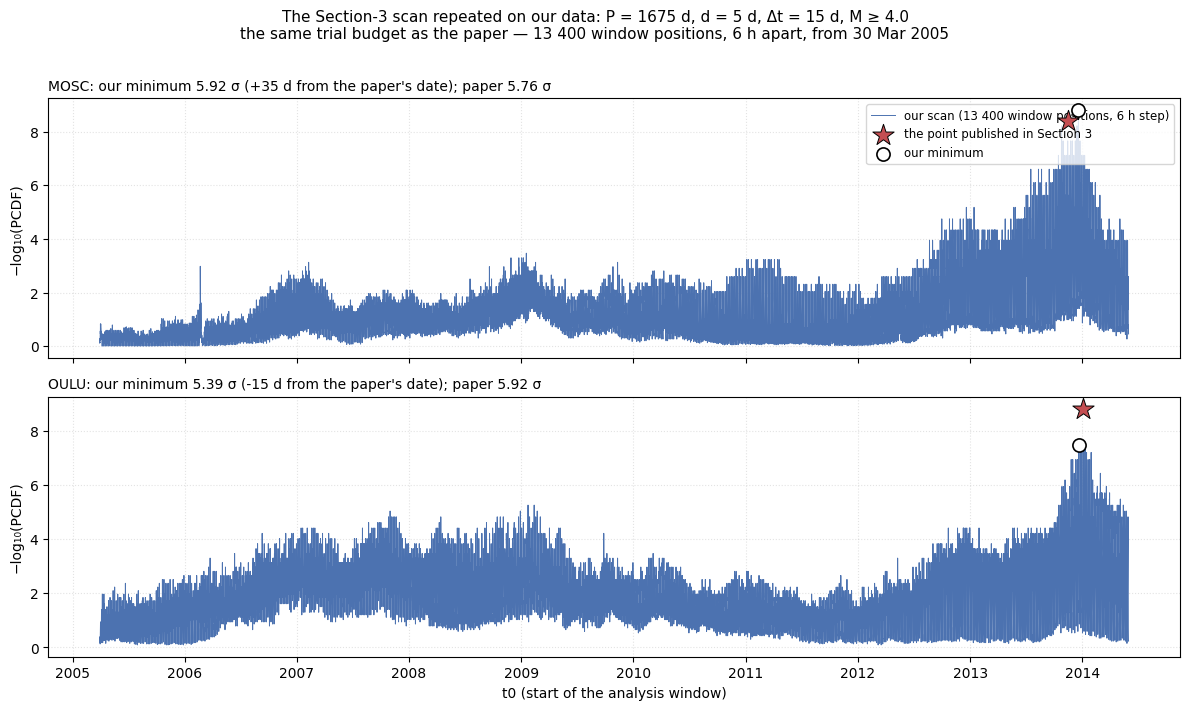

In [6]:
# JEZYK OPISOW NA RYSUNKACH (konwencja z 20260904a). Zeby dostac drugi komplet
# plikow: zmien stala i uruchom ponownie te komorke.
JEZYK = "en"

import matplotlib.pyplot as plt

OPISY = {
    "pl": dict(
        os_y="−log₁₀(PCDF)", os_x="t0 (początek okna analizy)",
        nasza="nasz skan (13 400 położeń okna, krok 6 h)",
        art="punkt opublikowany w sekcji 3",
        nasze_min="nasze minimum",
        tytul=("Skan sekcji 3 powtórzony na naszych danych: P = 1675 dni, d = 5 dni, "
               "Δt = 15 dni, M ≥ 4,0\nten sam budżet prób co w artykule — 13 400 położeń okna "
               "co 6 h od 30.03.2005"),
        pod="{st}: nasze minimum {ns:.2f} σ ({od:+d} dni od daty artykułu); artykuł {aa:.2f} σ",
    ),
    "en": dict(
        os_y="−log₁₀(PCDF)", os_x="t0 (start of the analysis window)",
        nasza="our scan (13 400 window positions, 6 h step)",
        art="the point published in Section 3",
        nasze_min="our minimum",
        tytul=("The Section-3 scan repeated on our data: P = 1675 d, d = 5 d, Δt = 15 d, "
               "M ≥ 4.0\nthe same trial budget as the paper — 13 400 window positions, "
               "6 h apart, from 30 Mar 2005"),
        pod="{st}: our minimum {ns:.2f} σ ({od:+d} d from the paper's date); paper {aa:.2f} σ",
    ),
}
OP = OPISY[JEZYK]

fig, osie = plt.subplots(len(podsum), 1, figsize=(12, 3.6 * len(podsum)), sharex=True)
osie = np.atleast_1d(osie)
for ax, (_, r) in zip(osie, podsum.iterrows()):
    df = skany[r["stacja"]]
    ax.plot(df["t0"], df["neglog10_PCDF"], color="#4C72B0", lw=0.7, label=OP["nasza"], zorder=3)
    ax.scatter([r["t0_artykulu"]], [-np.log10(r["PCDF_artykulu"])], marker="*", s=260,
               color="#C44E52", edgecolor="black", linewidth=0.7, zorder=6, label=OP["art"])
    ax.scatter([r["t0_nasz_najlepszy"]], [-np.log10(r["PCDF_nasz_najlepszy"])], marker="o", s=90,
               color="white", edgecolor="black", linewidth=1.2, zorder=6, label=OP["nasze_min"])
    ax.set_ylabel(OP["os_y"])
    ax.grid(ls=":", alpha=0.35)
    ax.set_title(OP["pod"].format(st=r["stacja"].upper(), ns=r["sigma_nasz"],
                                  od=int(r["odstep_dni"]), aa=norm.isf(r["PCDF_artykulu"])),
                 fontsize=10, loc="left")
osie[0].legend(loc="upper right", fontsize=8.5)
osie[-1].set_xlabel(OP["os_x"])
fig.suptitle(OP["tytul"], fontsize=11)
fig.tight_layout(rect=(0, 0, 1, 0.97))
_p = f"{RESULTS_DIR}/credo_replikacja_sekcja3_skan_{JEZYK}.png"
fig.savefig(_p, dpi=150)
print(f"Zapisano {_p}")
plt.show()


In [7]:
# KOMORKA 6 - PODSUMOWANIE DO DZIENNIKA.
print("=" * 78)
print("SEKCJA 3 - CO ODTWARZAMY, A CZEGO NIE")
print("=" * 78)
print(f"\n1. KATALOG TRZESIEN (jedyna opublikowana liczba niezalezna od CR):")
print(f"   M(Sm, P) artykul {MED_SM_ARTYKUL:.2f} | nasze {_med:.2f} | "
      f"{100 * (_med / MED_SM_ARTYKUL - 1):+.2f} %")

print("\n2. OPUBLIKOWANE PARY N+/N- W ICH WLASNYCH DATACH:")
for _, r in punkty3.iterrows():
    print(f"   {r['etykieta']:<34} {r['wariant']:<22} "
          f"artykul {r['Np_artykul']:>3}/{r['Nm_artykul']:>3} | "
          f"nasze {r['Np_nasze']:>3}/{r['Nm_nasze']:>3} | dN+ = {r['dNp']:+3d}, "
          f"dn = {r['dn']:+3d}")

print("\n3. ROWNANIE (4): " + ("spelnione wszedzie" if punkty3["rownanie4"].all()
                               else "NIE wszedzie spelnione - patrz komorka 2"))

print("\n4. SKAN 13 400 KANDYDATOW (ten sam budzet prob co artykul):")
for _, r in podsum.iterrows():
    print(f"   {r['stacja']}: nasze minimum {r['sigma_nasz']:.2f} sigma "
          f"({r['odstep_dni']:+d} dni od daty artykulu), artykul "
          f"{norm.isf(r['PCDF_artykulu']):.2f} sigma; "
          f"punktow bijacych artykul: {r['punktow_bijacych_artykul']} "
          f"({r['udzial_procent']:.2f} % siatki)")

print("\n5. PLIKI:")
for _f in ["replikacja_sekcja3_punkty.csv", "replikacja_sekcja3_skan_mosc_P1675.csv",
           "replikacja_sekcja3_skan_oulu_P1675.csv",
           "replikacja_sekcja3_skan_podsumowanie.csv",
           f"replikacja_sekcja3_skan_{JEZYK}.png"]:
    print(f"   {RESULTS_DIR}/{_f}")


SEKCJA 3 - CO ODTWARZAMY, A CZEGO NIE

1. KATALOG TRZESIEN (jedyna opublikowana liczba niezalezna od CR):
   M(Sm, P) artykul 859.55 | nasze 867.80 | +0.96 %

2. OPUBLIKOWANE PARY N+/N- W ICH WLASNYCH DATACH:
   Moskwa, przepis Augera bez zmian   jak wydrukowano        artykul 199/132 | nasze 194/138 | dN+ =  -5, dn =  +1
   Moskwa, t0 dostrojone skanem       jak wydrukowano        artykul 218/113 | nasze 212/120 | dN+ =  -6, dn =  +1
   Moskwa, t0 dostrojone skanem       faza kraty 07:37:12    artykul 218/113 | nasze 214/118 | dN+ =  -4, dn =  +1
   Oulu, t0 dostrojone skanem         jak wydrukowano        artykul 220/112 | nasze 217/116 | dN+ =  -3, dn =  +3

3. ROWNANIE (4): spelnione wszedzie

4. SKAN 13 400 KANDYDATOW (ten sam budzet prob co artykul):
   mosc: nasze minimum 5.92 sigma (+35 dni od daty artykulu), artykul 5.76 sigma; punktow bijacych artykul: 1 (0.01 % siatki)
   oulu: nasze minimum 5.39 sigma (-15 dni od daty artykulu), artykul 5.92 sigma; punktow bijacych artykul: